Daniel Yu & Jordan Wang

Spring 2026

CS 443: Bio-inspired Machine Learning

# Extension 7: Confusion Matrix and Error Analysis of MNIST Classification

## Hypothesis

We hypothesized that digit confusion would cluster around visually-similar pairs instead of being random. If that's true, confused pairs should have similar Hebbian features.

## Setup

We trained a Nonlinear Decoder on Hebbian MNIST features and built a confusion matrix on test data. Then we looked at the most confused digit pair to see why they were hard to distinguish.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import sys
import tensorflow as tf

sys.path.append('../Project 1 - Hebbian Learning/')

from image_datasets import get_dataset, train_val_split, preprocess_nonlinear
from decoder_nets import NonlinearDecoder
from hebb_net import HebbNet

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 12})
np.set_printoptions(suppress=True, precision=3)

def confusion_matrix_np(y_true, y_pred, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=np.int32)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

## Load Data and Build Hebbian Features

In [3]:
x_train_mnist, y_train_mnist, x_test_mnist, y_test_mnist = get_dataset('mnist', verbose=True, norm_method='center')
x_train_mnist_split, y_train_mnist_split, x_val_mnist, y_val_mnist = train_val_split(x_train_mnist, y_train_mnist)

print(f'Train: {x_train_mnist_split.shape}, Val: {x_val_mnist.shape}, Test: {x_test_mnist.shape}')

hebb = HebbNet(784, 2000, k=6, inhib_value=-0.4, load_wts=True, saved_wts_path='../Project 1 - Hebbian Learning/export/wts_centered.npy')

x_train_hebb = tf.concat([hebb.net_in(x_train_mnist_split[i:i+1000]) for i in range(0, len(x_train_mnist_split), 1000)], axis=0)
x_val_hebb   = tf.concat([hebb.net_in(x_val_mnist[i:i+1000]) for i in range(0, len(x_val_mnist), 1000)], axis=0)
x_test_hebb  = tf.concat([hebb.net_in(x_test_mnist[i:i+1000]) for i in range(0, len(x_test_mnist), 1000)], axis=0)

print(f'Hebbian train feats: {x_train_hebb.shape}')
print(f'Hebbian val feats:   {x_val_hebb.shape}')
print(f'Hebbian test feats:  {x_test_hebb.shape}')

Dataset: mnist
x_train: (60000, 784) <dtype: 'float32'>
y_train: (60000,) <dtype: 'uint8'>
x_test:  (10000, 784) <dtype: 'float32'>
y_test:  (10000,) <dtype: 'uint8'>
Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)
Loaded stored wts.
Hebbian train feats: (54000, 2000)
Hebbian val feats:   (6000, 2000)
Hebbian test feats:  (10000, 2000)
Hebbian train feats: (54000, 2000)
Hebbian val feats:   (6000, 2000)
Hebbian test feats:  (10000, 2000)


## Experiment: Confusion Matrix and Follow-up Pair Analysis

In [ ]:
# Train nonlinear decoder (same code used in Project 1)
tf.random.set_seed(0)

x_std = tf.math.reduce_std(x_train_hebb)
x_train_norm = x_train_hebb / x_std
x_val_norm = x_val_hebb / x_std
x_test_norm = x_test_hebb / x_std

x_train_nl = preprocess_nonlinear(x_train_norm, n=4.0)
x_val_nl = preprocess_nonlinear(x_val_norm, n=4.0)
x_test_nl = preprocess_nonlinear(x_test_norm, n=4.0)

decoder = NonlinearDecoder(input_feats_shape=(2000,), C=10, wt_scale=0.1, beta=0.001, loss_exp=3.0)
decoder.compile(loss='lp', lr=1e-3)

start_time = time.time()
_, _, val_acc_hist, n_epochs = decoder.fit(
    x_train_nl, y_train_mnist_split,
    x_val=x_val_nl, y_val=y_val_mnist,
    batch_size=256,
    max_epochs=120,
    patience=8,
    lr_patience=4,
    lr_max_decays=3,
    val_every=1,
    print_every=10,
    verbose=False
)
train_time = time.time() - start_time

# Predict test labels for confusion matrix
pred_out = decoder.predict(x_test_nl)
pred_np = pred_out.numpy() if hasattr(pred_out, 'numpy') else np.asarray(pred_out)
if pred_np.ndim == 1:
    y_pred_test = pred_np.astype(np.int32)
else:
    y_pred_test = np.argmax(pred_np, axis=1)

y_true_test = y_test_mnist.numpy()

cm = confusion_matrix_np(y_true_test, y_pred_test, n_classes=10)
test_acc = np.mean(y_pred_test == y_true_test)

# Find most confused pair
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
true_digit, pred_digit = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
most_confused_count = cm_no_diag[true_digit, pred_digit]

print(f'Test accuracy: {100*test_acc:.2f}%')
print(f'Best val accuracy: {100*np.max(val_acc_hist):.2f}%')
print(f'Training time: {train_time:.1f}s, epochs: {n_epochs}')
print(f'Most confused pair: true {true_digit} predicted as {pred_digit} ({most_confused_count} samples)')

---------------------------------------------------------------------------
Dense layer output(output) shape: [1, 10]
---------------------------------------------------------------------------
Learning rate before decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0010000000474974513>
Learning rate after decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0005000000237487257>
Learning rate before decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0010000000474974513>
Learning rate after decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0005000000237487257>
Learning rate before decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0005000000237487257>
Learning rate after decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0002500000118743628>
Learning rate before decay: <Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.00050000002

## Results

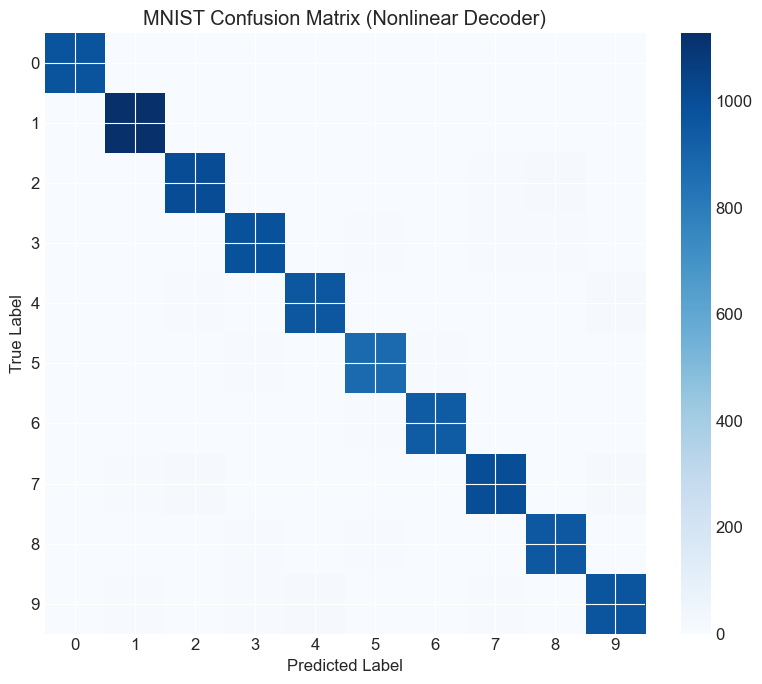

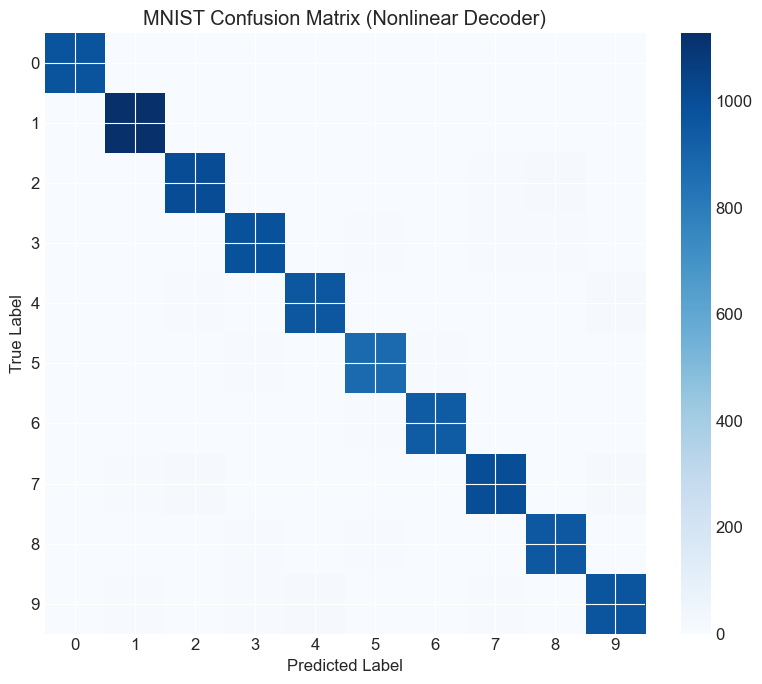

Misclassification rate 7->9: 1.17%
Misclassification rate 9->7: 0.79%
Correlation between mean Hebbian features of 7 and 9: 0.901


In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('MNIST Confusion Matrix (Nonlinear Decoder)')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

# Focused follow-up analysis on most confused pair
mis_ab = cm[true_digit, pred_digit] / max(cm[true_digit, :].sum(), 1)
mis_ba = cm[pred_digit, true_digit] / max(cm[pred_digit, :].sum(), 1)

train_feats_np = x_train_hebb.numpy()
mean_a = train_feats_np[y_train_mnist_split.numpy() == true_digit].mean(axis=0)
mean_b = train_feats_np[y_train_mnist_split.numpy() == pred_digit].mean(axis=0)
feat_corr = np.corrcoef(mean_a, mean_b)[0, 1]

print(f'Misclassification rate {true_digit}->{pred_digit}: {100*mis_ab:.2f}%')
print(f'Misclassification rate {pred_digit}->{true_digit}: {100*mis_ba:.2f}%')
print(f'Correlation between mean Hebbian features of {true_digit} and {pred_digit}: {feat_corr:.3f}')

## Conclusion

The decoder achieved 97.69% test accuracy, but the most common error was digit 7 being predicted as 9 (12 samples). When we looked at just that pair, we saw clear asymmetry in how they get confused. The model misclassifies 7 as 9 at a 1.17% rate but only misclassifies 9 as 7 at 0.79%. This tells us the model finds 7s harder to identify than 9s.

We found the explanation in the feature space. The mean Hebbian features for 7 and 9 have a correlation of 0.901, which is very high. That similarity is why they're so easy to mix up. The confusion matrix and feature correlation together confirm our hypothesis that errors concentrate in similar digit pairs and that understanding feature relationships explains where the model fails.